# Lab 6: Image Smoothing and Sharpening

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import copy

## Helper Functions

In [2]:
def box_filt(n):
    kernel = np.ones((n, n), np.float32) / (n * n)
    return kernel


def apply_filters(image_input, box, filt_size):
    pad_size = int(np.ceil(filt_size / 2))
    image_padded = np.pad(image_input, pad_width=((pad_size, pad_size), (pad_size, pad_size)), mode='symmetric')
    image_box = copy.deepcopy(image_input)
    row, column = image_input.shape
    for i in range(row):
        for j in range(column):
            patch_curr = image_padded[i:i + filt_size, j:j + filt_size]
            results_box = box * patch_curr
            image_box[i, j] = np.sum(results_box)
    return image_box

## Task 1: Histogram Equalization

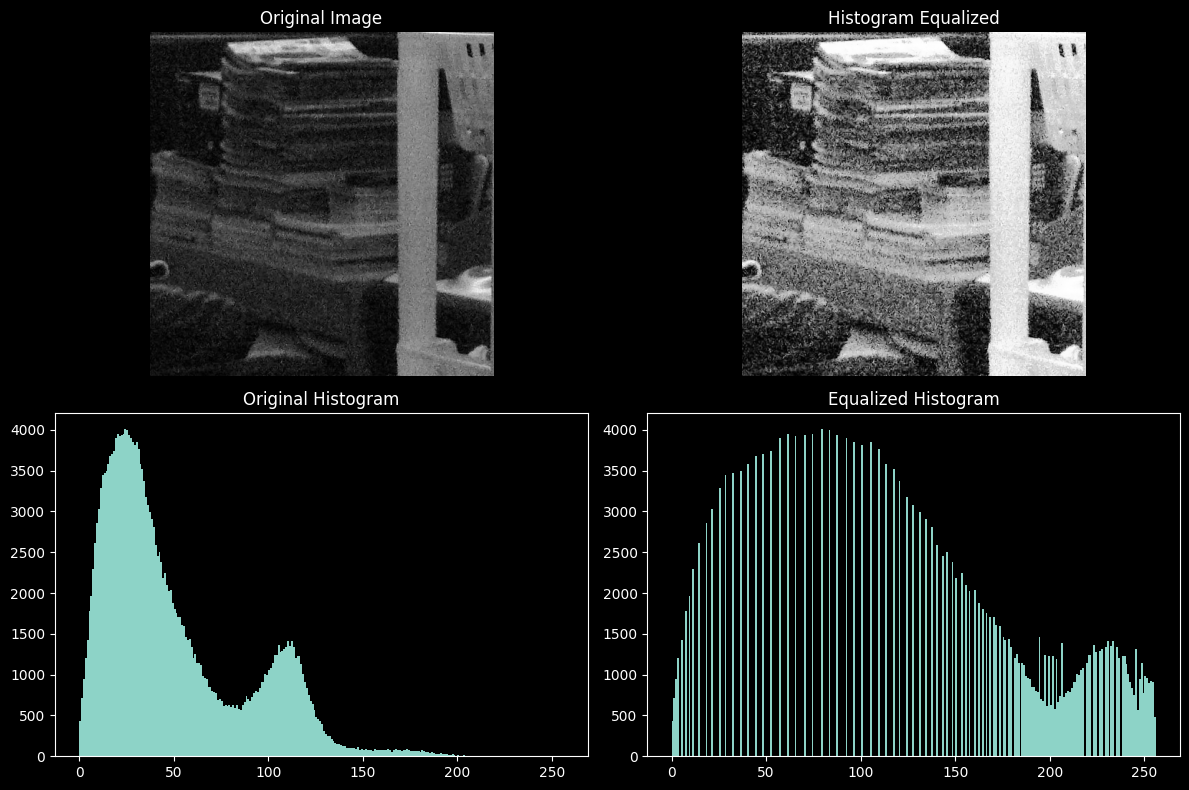

In [3]:
image = cv2.imread('noise.png', cv2.IMREAD_GRAYSCALE)
equalized = cv2.equalizeHist(image)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(equalized, cmap='gray')
plt.title('Histogram Equalized')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.hist(image.ravel(), bins=256, range=(0, 256))
plt.title('Original Histogram')

plt.subplot(2, 2, 4)
plt.hist(equalized.ravel(), bins=256, range=(0, 256))
plt.title('Equalized Histogram')

plt.tight_layout()
plt.show()

## Task 2: Gaussian Filter

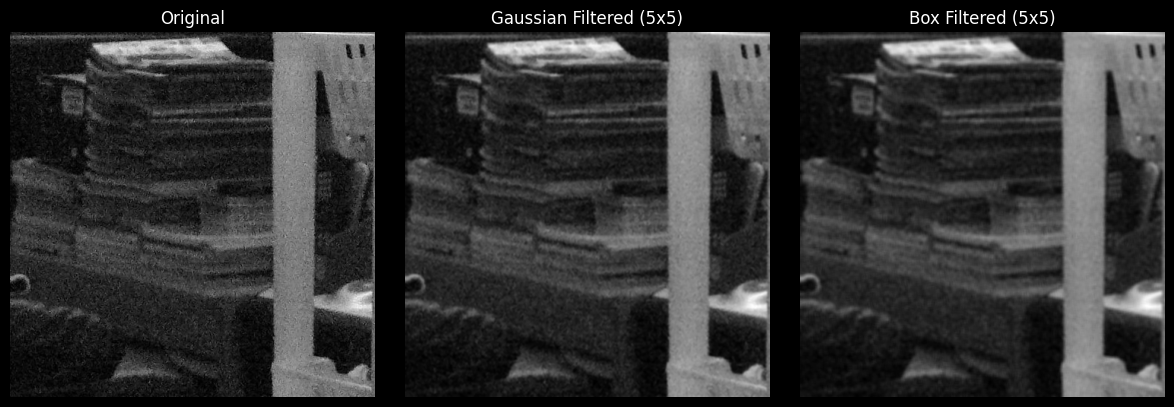

In [4]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
gaussian_filtered = cv2.GaussianBlur(image, (5, 5), 0)
plt.imshow(gaussian_filtered, cmap='gray')
plt.title('Gaussian Filtered (5x5)')
plt.axis('off')

plt.subplot(1, 3, 3)
box_kernel = box_filt(5)
box_filtered = cv2.filter2D(image, -1, box_kernel)
plt.imshow(box_filtered, cmap='gray')
plt.title('Box Filtered (5x5)')
plt.axis('off')

plt.tight_layout()
plt.show()

## Task 3: Unsharp Masking

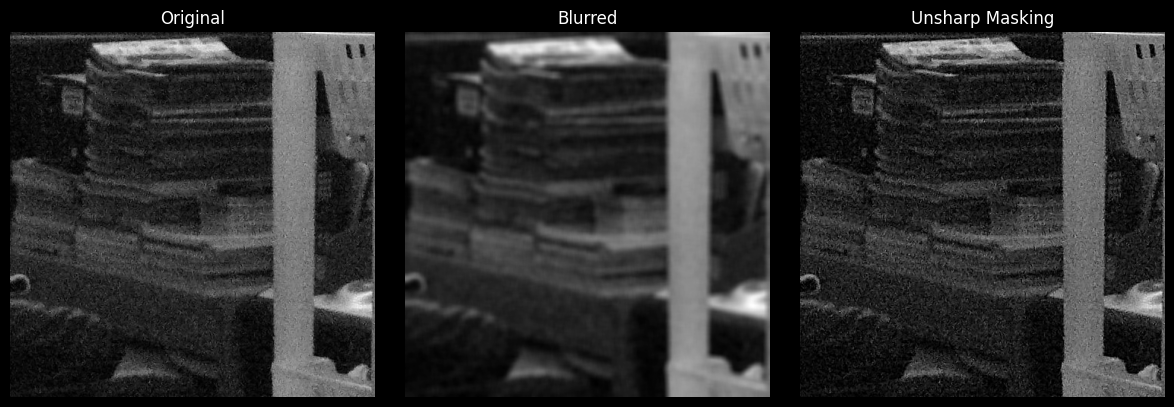

In [5]:
blurred = cv2.GaussianBlur(image, (9, 9), 10)
unsharp_image = cv2.addWeighted(image, 1.5, blurred, -0.5, 0)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(blurred, cmap='gray')
plt.title('Blurred')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(unsharp_image, cmap='gray')
plt.title('Unsharp Masking')
plt.axis('off')

plt.tight_layout()
plt.show()

## Task 4: Parameter Variation

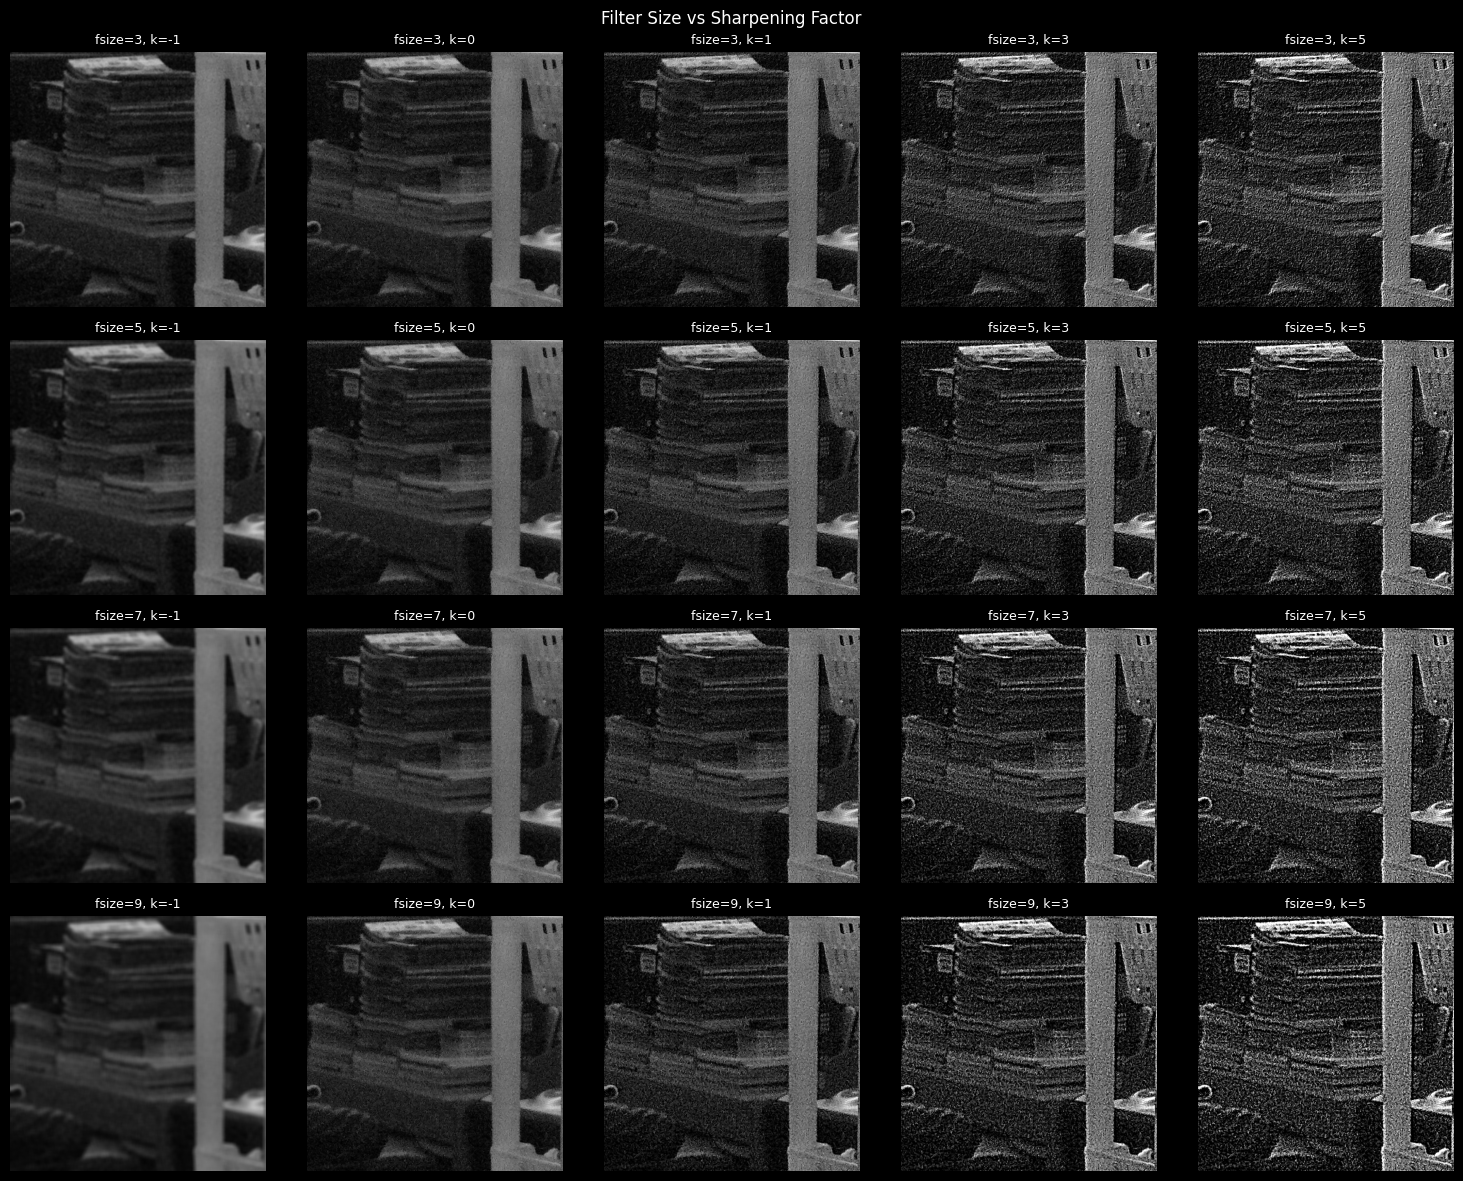

In [6]:
image_input = cv2.imread('noise.png', 0).astype('float32') / 255

filter_sizes = [3, 5, 7, 9]
k_values = [-1, 0, 1, 3, 5]

plt.figure(figsize=(15, 12))

for i, filt_size in enumerate(filter_sizes):
    for j, k in enumerate(k_values):
        box = box_filt(filt_size)
        image_blur = apply_filters(image_input, box, filt_size)
        image_diff = image_input - image_blur
        image_sharp = image_input + k * image_diff
        
        plt.subplot(len(filter_sizes), len(k_values), i * len(k_values) + j + 1)
        plt.imshow(image_sharp, cmap='gray', vmin=0, vmax=1)
        plt.title(f'fsize={filt_size}, k={k}', fontsize=9)
        plt.axis('off')

plt.suptitle('Filter Size vs Sharpening Factor')
plt.tight_layout()
plt.show()